# Data Loading and Mapping

In [1]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('filtered_data.csv')

In [3]:
df.head()

,_BMI5,_BMI5CAT,_AGE_G,_AGE80,_AGE65YR,_INCOMG1,INCOME3,_SMOKER3,_RFSMOK3,SMOKDAY2,...,MENTHLTH,ADDEPEV3,LANDSEX3,SEXVAR,DIABETE4,PERSDOC3,PRIMINS2,_URBSTAT,_IMPRACE,CHILDREN
0,2249.0,2.0,6.0,78.0,2.0,9.0,99.0,4.0,1.0,NaN,...,88.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,1.0,88.0
1,2583.0,3.0,6.0,80.0,2.0,7.0,11.0,3.0,1.0,3.0,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
2,2253.0,2.0,5.0,59.0,1.0,9.0,99.0,1.0,2.0,1.0,...,88.0,2.0,1.0,1.0,3.0,3.0,1.0,1.0,1.0,88.0
3,2509.0,3.0,6.0,80.0,2.0,4.0,6.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,3.0,1.0,1.0,88.0
4,1977.0,2.0,4.0,47.0,1.0,2.0,3.0,4.0,1.0,NaN,...,88.0,2.0,1.0,1.0,3.0,1.0,5.0,1.0,1.0,88.0


In [4]:
df.columns

Index(['_BMI5', '_BMI5CAT', '_AGE_G', '_AGE80', '_AGE65YR', '_INCOMG1',
       'INCOME3', '_SMOKER3', '_RFSMOK3', 'SMOKDAY2', 'CVDINFR4', 'CVDCRHD4',
       'ASTHMA3', '_LTASTH1', 'CHCKDNY2', 'MARITAL', 'EDUCA', '_EDUCAG',
       'GENHLTH', 'EXERANY2', '_TOTINDA', 'HAVARTH4', '_DRDXAR2', 'MENTHLTH',
       'ADDEPEV3', 'LANDSEX3', 'SEXVAR', 'DIABETE4', 'PERSDOC3', 'PRIMINS2',
       '_URBSTAT', '_IMPRACE', 'CHILDREN'],
      dtype='str')

In [5]:
chosen_columns = ['_BMI5', '_AGE_G', 'INCOME3', '_SMOKER3', 'CVDINFR4', 'CVDCRHD4', 
                 'ASTHMA3', 'CHCKDNY2', 'MARITAL', 'EDUCA', 'GENHLTH', 'EXERANY2',
                 'HAVARTH4', 'MENTHLTH', 'ADDEPEV3', 'SEXVAR', 'PERSDOC3', 'PRIMINS2',
                 '_URBSTAT', 'CHILDREN', 'DIABETE4']

df_eda = df[chosen_columns]

In [6]:
df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,2249.0,6.0,99.0,4.0,2.0,2.0,2.0,2.0,3.0,4.0,...,1.0,1.0,88.0,2.0,2.0,2.0,3.0,1.0,88.0,3.0
1,2583.0,6.0,11.0,3.0,2.0,1.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
2,2253.0,5.0,99.0,1.0,2.0,2.0,2.0,2.0,6.0,5.0,...,1.0,1.0,88.0,2.0,1.0,3.0,1.0,1.0,88.0,3.0
3,2509.0,6.0,6.0,4.0,2.0,2.0,2.0,2.0,1.0,6.0,...,1.0,1.0,88.0,2.0,1.0,1.0,3.0,1.0,88.0,3.0
4,1977.0,4.0,3.0,4.0,2.0,2.0,2.0,2.0,5.0,5.0,...,2.0,2.0,88.0,2.0,1.0,1.0,5.0,1.0,88.0,3.0


In [7]:
column_mapper = {
    'DIABETE4': {
        1: 'Yes',
        2: np.nan,
        3: 'No',
        4: 'Yes',
        7: np.nan,
        9: np.nan
    },
    '_AGE_G': {
        1: '18-24',
        2: '25-34',
        3: '35-44',
        4: '45-54',
        5: '55-64',
        6: '65+'
    },
    'INCOME3': {
        1: '< \$10k', 
        2: '\$10k - \$15k', 
        3: '\$15k - \$20k', 
        4: '\$20k - \$25k', 
        5: '\$25k - \$35k', 
        6: '\$35k - \$50k', 
        7: '\$50k - \$75k', 
        8: '\$75k - \$100k', 
        9: '\$100k - \$150k', 
        10: '\$150k - \$200k', 
        11: '>= \$200k', 
        77: 'Not Sure', 
        99: 'Refused'
    },
    '_SMOKER3': {
        1: 'Current smoker - every day',
        2: 'Current smoker - some days',
        3: 'Former smoker',
        4: 'Never smoked',
        9: 'Don’t know/Refused'
    },
    'GENHLTH': {
        1: 'Excellent',
        2: 'Very good',
        3: 'Good',
        4: 'Fair',
        5: 'Poor',
        7: 'Don’t know/Not Sure',
        9: 'Refused'
    },
    'EDUCA': {
        1: 'Never attended/Kindergarten',
        2: 'Elementary',
        3: 'Some high school',
        4: 'High school graduate',
        5: 'Some college/Technical school',
        6: 'College graduate',
        9: 'Refused'
    },
    'MARITAL': {
        1: 'Married',
        2: 'Divorced',
        3: 'Widowed',
        4: 'Separated',
        5: 'Never married',
        6: 'Member of unmarried couple',
        9: 'Refused'
    },
    'SEXVAR': {
        1: 'Male',
        2: 'Female'
    },
    'PERSDOC3': {
        1: 'Yes, only one',
        2: 'More than one',
        3: 'No',
        7: 'Don’t know/Not Sure',
        9: 'Refused'
    },
    'PRIMINS2': {
        1: 'Employer/Union plan',
        2: 'Private plan',
        3: 'Medicare',
        4: 'Medigap',
        5: 'Medicaid',
        6: 'CHIP',
        7: 'Military/VA',
        8: 'Indian Health Service',
        9: 'State sponsored plan',
        10: 'Other government program',
        88: 'No coverage',
        77: 'Don’t know',
        99: 'Refused'
    },
    '_URBSTAT': {
        1: 'Urban',
        2: 'Rural'
    },
    'EXERANY2': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CVDINFR4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CVDCRHD4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'ASTHMA3':  {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'CHCKDNY2': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'HAVARTH4': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
    'ADDEPEV3': {1: 'Yes', 2: 'No', 7: 'Don’t know', 9: 'Refused'},
}

for column in df_eda.columns:
    if column in column_mapper.keys():
        df_eda[column] = df_eda[column].map(column_mapper[column])

df_eda['_BMI5'] = df_eda['_BMI5'] / 100.0
df_eda['CHILDREN'] = df['CHILDREN'].replace({
    88: 0,
    99: 'Refused'
})
df_eda['MENTHLTH'] = df['MENTHLTH'].replace({
    88: 0,
    77: 'Don’t know', 
    99: 'Refused'
})

df_eda.head()

,_BMI5,_AGE_G,INCOME3,_SMOKER3,CVDINFR4,CVDCRHD4,ASTHMA3,CHCKDNY2,MARITAL,EDUCA,...,EXERANY2,HAVARTH4,MENTHLTH,ADDEPEV3,SEXVAR,PERSDOC3,PRIMINS2,_URBSTAT,CHILDREN,DIABETE4
0,22.49,65+,Refused,Never smoked,No,No,No,No,Widowed,High school graduate,...,Yes,Yes,0.0,No,Female,More than one,Medicare,Urban,0.0,No
1,25.83,65+,>= \$200k,Former smoker,No,Yes,No,No,Married,College graduate,...,Yes,Yes,0.0,No,Male,"Yes, only one",Medicare,Urban,0.0,No
2,22.53,55-64,Refused,Current smoker - every day,No,No,No,No,Member of unmarried couple,Some college/Technical school,...,Yes,Yes,0.0,No,Male,No,Employer/Union plan,Urban,0.0,No
3,25.09,65+,\$35k - \$50k,Never smoked,No,No,No,No,Married,College graduate,...,Yes,Yes,0.0,No,Male,"Yes, only one",Medicare,Urban,0.0,No
4,19.77,45-54,\$15k - \$20k,Never smoked,No,No,No,No,Never married,Some college/Technical school,...,No,No,0.0,No,Male,"Yes, only one",Medicaid,Urban,0.0,No


# Missing Values Analysis

Missing values analysis is very interesting here because we can treat 'Don't Know' or 'Refused' answer as missing values or treat them as a feature on their own. We must analyze whether these values happens completely randomly (MCAR), or does it has a unique pattern that we can study (either MAR or MNAR). If its the former then I think we can safely drop the data (assuming we still have some decent amount left), if its the latter then we can try imputing the missing data, either with mean or mode or even model-based imputation.

For analysis purpose I will be treating them as missing values first.

In [9]:
df_miss = df_eda.copy()

na_values = [
    'Refused',
    'Not Sure',
    'Don’t know',
    'Don’t know/Not Sure', 
    'Don’t know/Refused', 
]

df_miss = df_miss.replace(na_values, np.nan)

In [10]:
df_miss.shape

(457670, 21)

In [11]:
df_miss.isna().sum()

_BMI5       43037
_AGE_G          0
INCOME3     87423
_SMOKER3    32022
CVDINFR4     3115
CVDCRHD4     4578
ASTHMA3      1861
CHCKDNY2     1979
MARITAL      4222
EDUCA        2363
GENHLTH      1310
EXERANY2     1315
HAVARTH4     2573
MENTHLTH     8156
ADDEPEV3     2664
SEXVAR          0
PERSDOC3     4613
PRIMINS2    18544
_URBSTAT    14623
CHILDREN     9379
DIABETE4     4429
dtype: int64

Well well well, this already denies the MCAR hypothesis because there are clearly some columsn that has way higher missing values than other. lets specifically look at the INCOME3 column. This column has 87k data missing out of 457k samples, that is nearly 20% of the data misisng, which can be pretty bad to lose. Since theres clearly a pattern already, mindlessly dropping the data should be saved for last option. We need to try to find a way to manipulate these missing data (either by imputing or just straight up keeping them as a 'unknown' value). Let's see if theres some unique pattern that we can immediately identify by checking the missingness with the missingno library.

<Axes: >

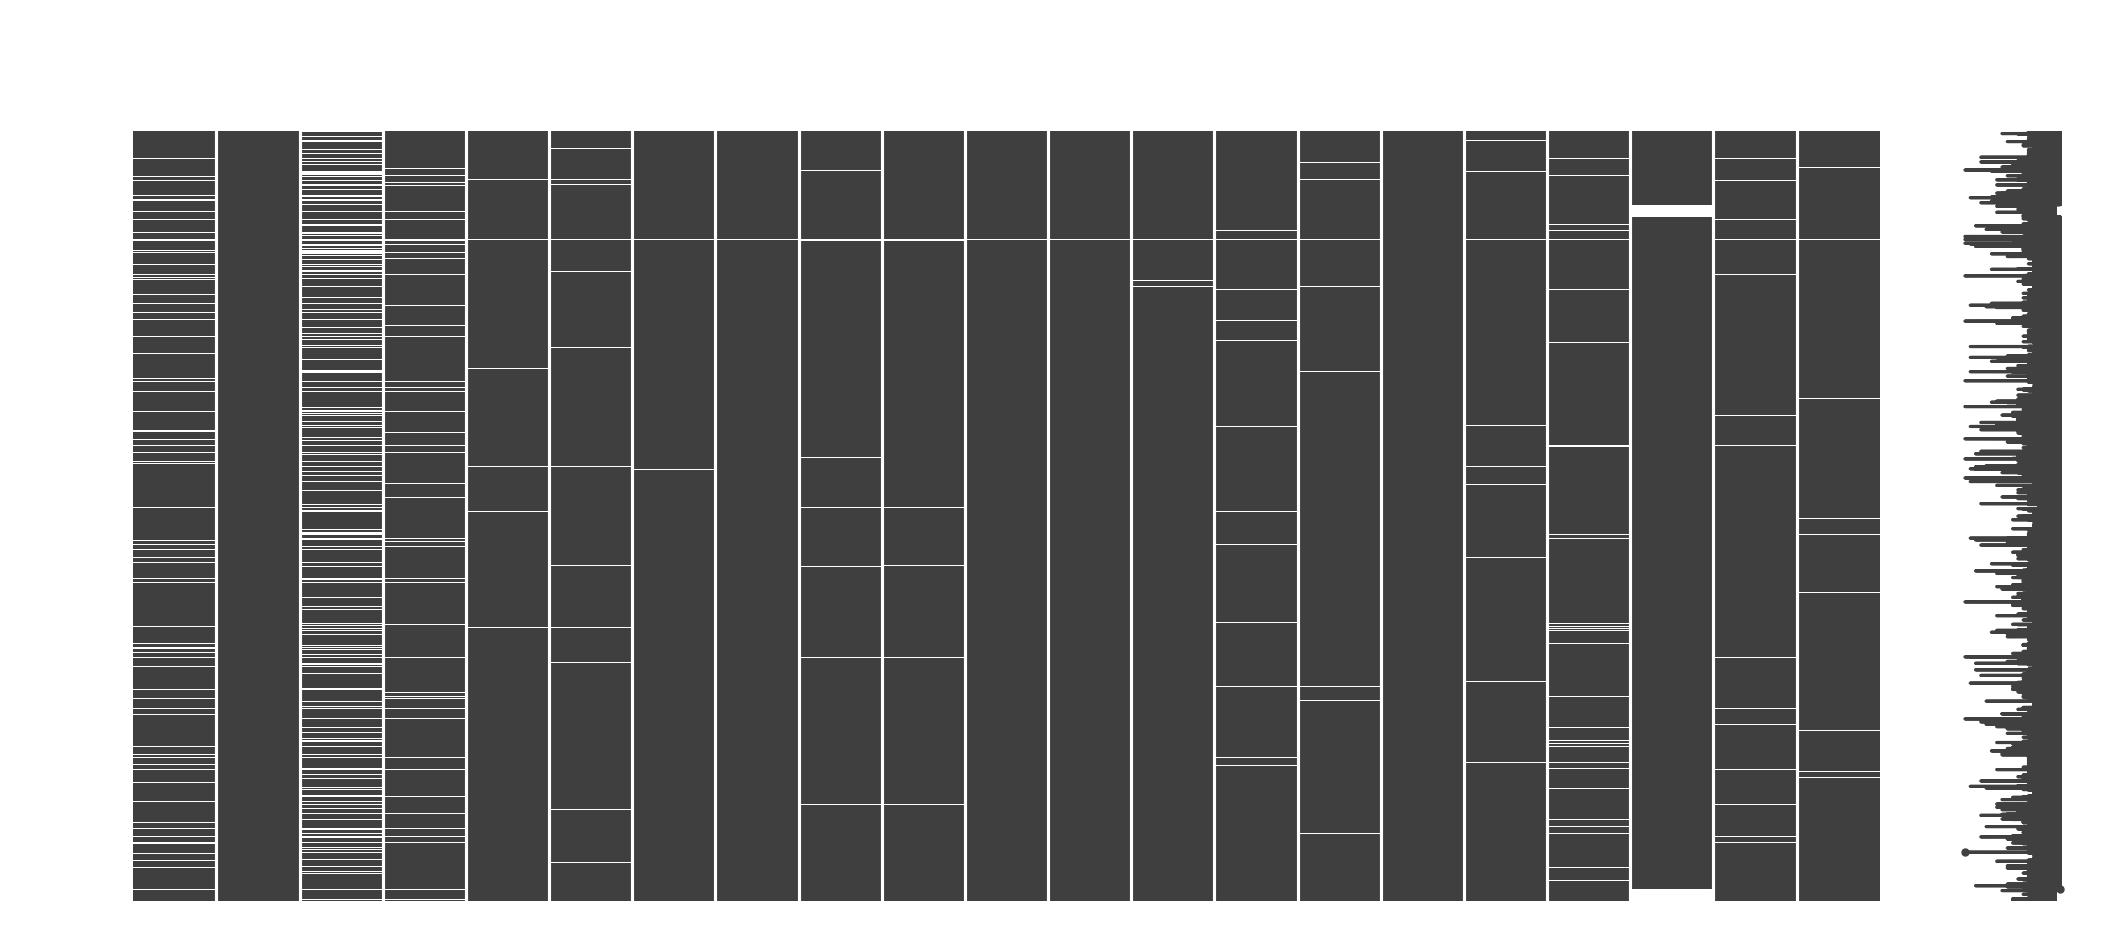

In [12]:
import missingno as msno

msno.matrix(df_miss)

<Axes: >

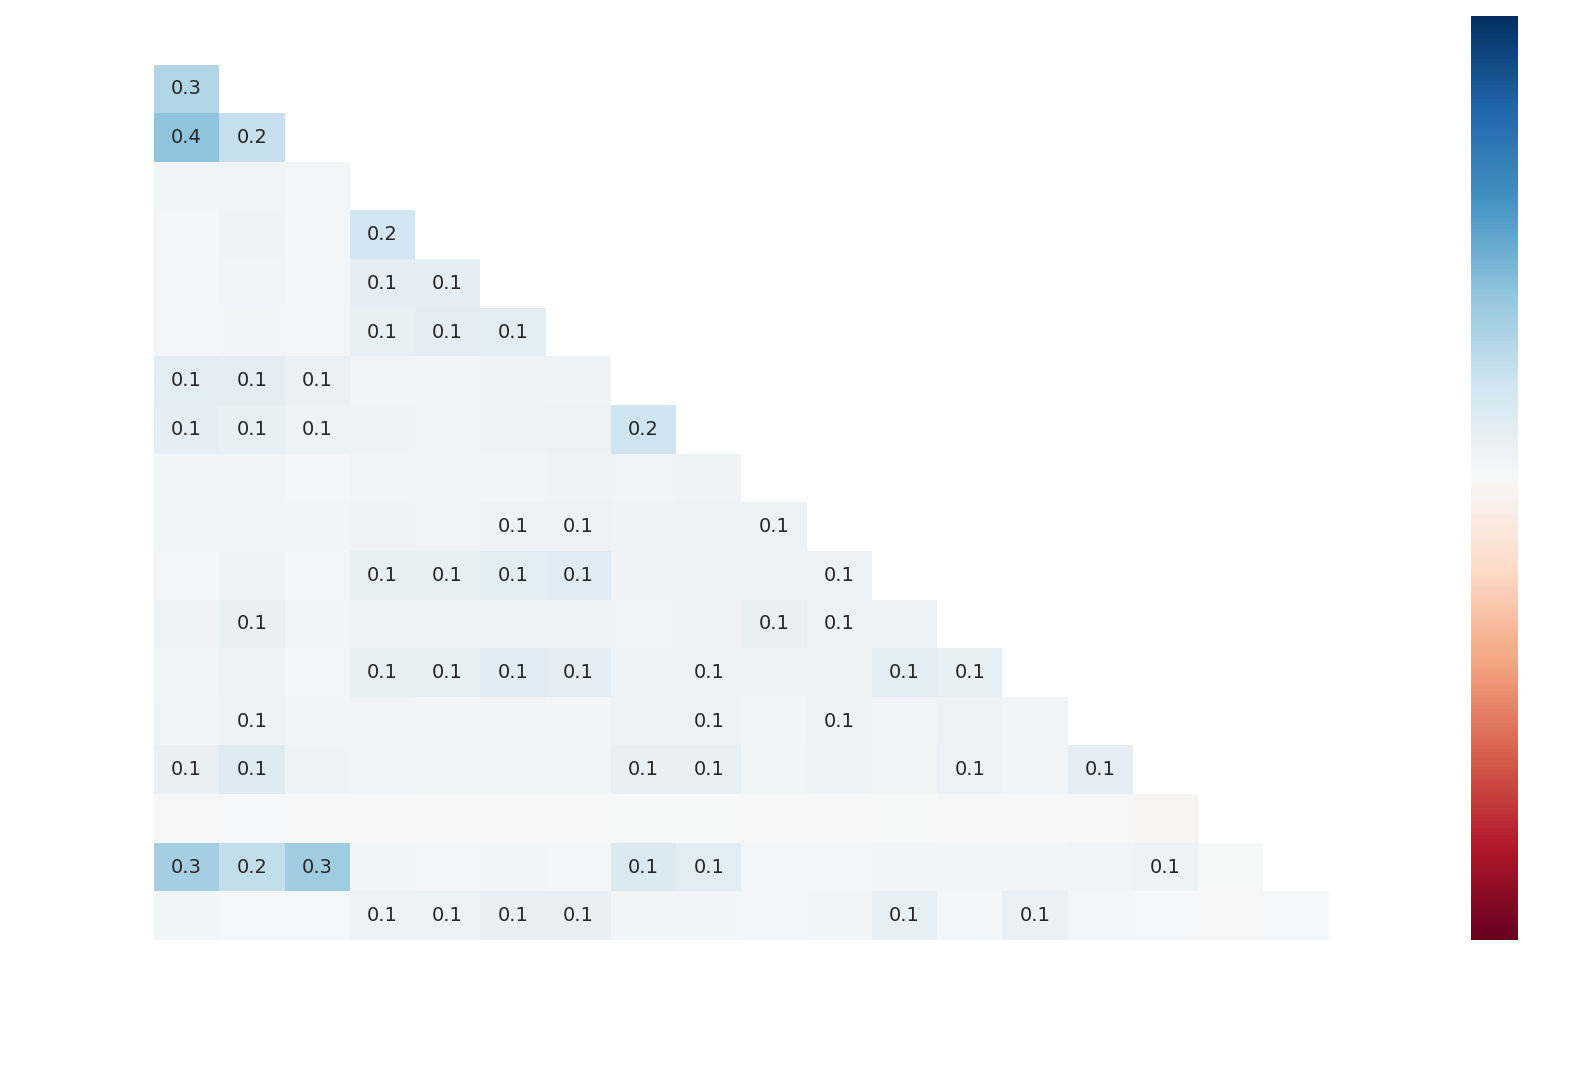

In [13]:
msno.heatmap(df_miss)

An interesting result, there are some weak correlations between _BMI5, INCOME3, and _SMOKER3. Coincidentally, these 3 columns are also the columns that has a large amount of missing values (30k+), so this may have happened due to sample size sensitivity. Let's further check with dendograms to check these correlations further.

<Axes: >

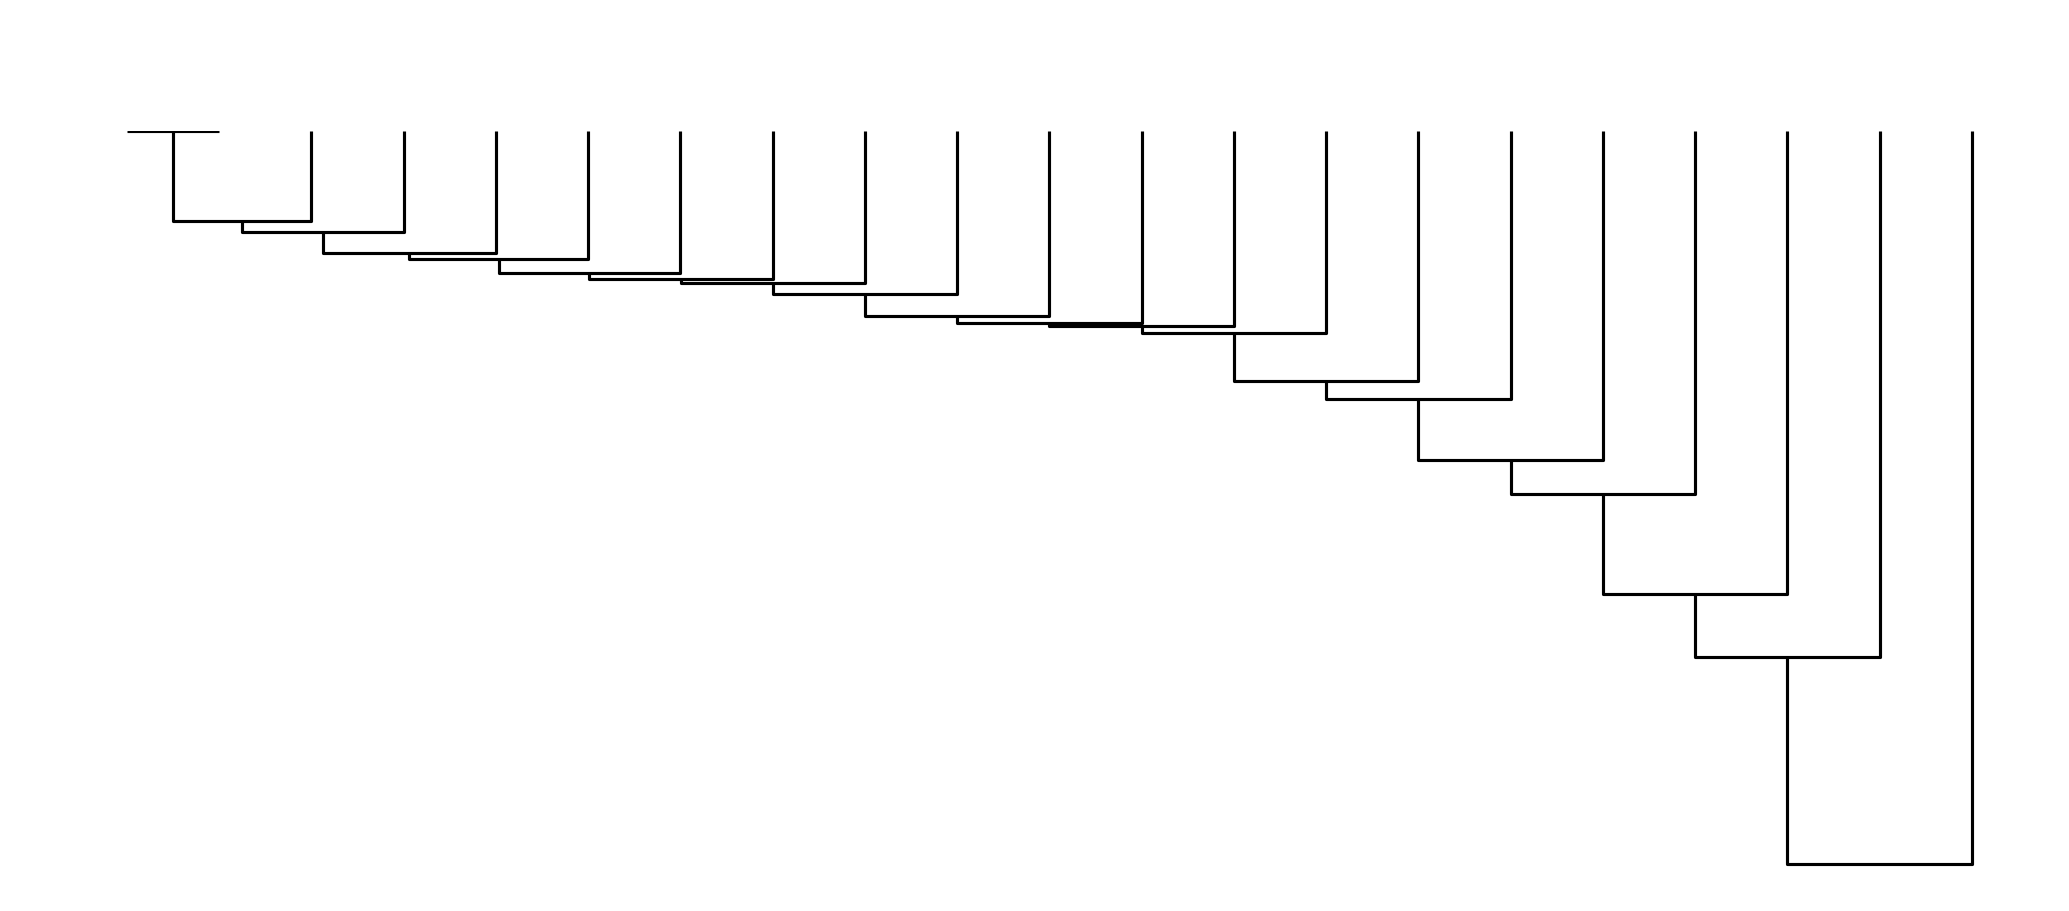

In [22]:
msno.dendrogram(df_miss)

Okay so this confirms the sample sensitivity assumption that we had because _SMOKER3, _BMI5, and INCOME3 was merged very late and has high wand values. This means that, even though some of them might have went missing together (they have some correlation as shown at the heatmap) the reason for the misses is completely different (they are not clusterable as shown at the dendogram).

It is now concluded that this is clearly a MAR/MNAR case. Since the dendograms and the heatmap doesn't yield an immediate insight, we now need to analyze deeper some of the columns that has alarming missing values rate to see if we can impute them using other observed columns in this dataset.

Since there's a lot of columns in this dataset, and not that much time limit, We've decided that we only will be doing EDA and model-based imputaiton to only 3 of the most severe columns, which are _SMOKER3, _BMI5, INCOME3. The rest of the column will be imputed with mode, median, or mean only.   

Adapting to the time limit, I've decided that I will directly use xgboost's feature importance for the feature selection instead of manual EDA. If there's some free time left to polish this before final pitching, I will make sure to include manual EDA

## EDA Setup

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from pypalettes import load_cmap

neon_cmap = load_cmap('Neon')
neon_colors = np.array(neon_cmap.colors)

sns.set_palette(sns.color_palette(neon_colors))

custom_rc_dark = {
    "figure.facecolor": "none",
    "axes.facecolor": "none",
    "savefig.facecolor": "none",
    
    "text.color": "#FFFFFF",
    "axes.labelcolor": "#FFFFFF",
    "xtick.color": "#FFFFFF",
    "ytick.color": "#FFFFFF",
    "axes.edgecolor": "#FFFFFF", 
    
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    
    "axes.grid.axis": "y",
    "grid.color": "#FFFFFF",
    "grid.alpha": 0.2,
    "grid.linestyle": "--",
    
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
}

sns.set_context("talk", rc=custom_rc_dark)
plt.rcParams.update(custom_rc_dark)

## Direct XGBoost-based feature selection

We'd need to encode the categorical first into an integer. Since XGBoost is a decision tree-based model, I think we can safely use ordinal encoder for all columns. The reason why is that even if we do one hot encoder for the nominal columns, the model will still do the same thing anyway, for example:

Let's say feature X == 'go' is important for a decision. Let's then assume this is gonna be encoded into the number '2' with ordinal encoder and encoded into a dedicated binary column 'is_X_Go' for one hot encoder.

**on ordinal-encoder**

if features X >= 1.5 and features X <= 2, then decision

**on one-hot-encoder**

if features is_X_Go == 1, then decision

XGBoost can handle both without any issues, so let's go straight into using ordinal encoder to save more time. Of course, like before, if there's extra time to experiment with this I will also try to add it.

In [15]:
from sklearn.preprocessing import OrdinalEncoder

age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
income_order = ['< \$10k', '\$10k - \$15k', '\$15k - \$20k', '\$20k - \$25k', '\$25k - \$35k', 
                '\$35k - \$50k', '\$50k - \$75k', '\$75k - \$100k', '\$100k - \$150k', 
                '\$150k - \$200k', '>= \$200k']
health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
edu_order = ['Never attended/Kindergarten', 'Elementary', 'Some high school', 
             'High school graduate', 'Some college/Technical school', 'College graduate']

ordinal_cols_ordered = {
    '_AGE_G': age_order,
    'INCOME3': income_order,
    'GENHLTH': health_order,
    'EDUCA': edu_order
}


categorical_cols = [
    'DIABETE4', '_SMOKER3', 'MARITAL', 'SEXVAR', 'PERSDOC3', 
    'PRIMINS2', '_URBSTAT', 'EXERANY2', 'CVDINFR4', 'CVDCRHD4', 
    'ASTHMA3', 'CHCKDNY2', 'HAVARTH4', 'ADDEPEV3'
]

df_encoded = df_miss.copy()

for col, order in ordinal_cols_ordered.items():
    mapping = {val: i for i, val in enumerate(order)}
    df_encoded[col] = df_encoded[col].map(mapping)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[categorical_cols] = oe.fit_transform(df_encoded[categorical_cols].astype(str))

for col in categorical_cols:
    df_encoded.loc[df_eda[col].isna(), col] = np.nan

df_encoded['MENTHLTH'] = pd.to_numeric(df_encoded['MENTHLTH'], errors='coerce')
df_encoded['CHILDREN'] = pd.to_numeric(df_encoded['CHILDREN'], errors='coerce')
df_encoded.drop(columns='DIABETE4', inplace=True)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'


In [16]:
from xgboost import XGBClassifier, XGBRegressor

def plot_imputation_importance(importances, target_col, file_name):
    
    plt.figure(figsize=(10, 6))
    
    color = neon_colors[4]
    
    ax = importances.sort_values(ascending=True).plot(kind='barh', color=color, width=0.7)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width(), p.get_y() + p.get_height()/2),
                    ha='left', va='center', color='#FFFFFF', 
                    fontsize=10, xytext=(5, 0), textcoords='offset points')

    plt.title(f'Top Predictors for Imputing: {target_col}', 
              fontsize=14, weight='bold', color='#FFFFFF', pad=20)
    plt.xlabel('Average Gain (Importance)', fontsize=11, color='#FFFFFF')
    plt.ylabel('')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#FFFFFF')
    ax.spines['left'].set_color('#FFFFFF')
    ax.tick_params(axis='x', colors='#FFFFFF')
    ax.tick_params(axis='y', colors='#FFFFFF')
    ax.grid(True, axis='x', color='#FFFFFF', alpha=0.1, linestyle='--')

    plt.savefig(f'./outputs/imputations/{file_name}', transparent=True, dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

def get_imputation_features_xgb(df, target_col, file_name, is_categorical=True):
    data_complete = df.dropna(subset=[target_col])
    if len(data_complete) > 50000:
        data_complete = data_complete.sample(n=50000, random_state=42)
    
    X = data_complete.drop(columns=[target_col])
    y = data_complete[target_col]
    
    if is_categorical:
        model = XGBClassifier(
            tree_method='hist', 
            random_state=42,
            verbosity=0
        )
    else:
        model = XGBRegressor(
            tree_method='hist', 
            random_state=42,
            verbosity=0
        )
    
    model.fit(X, y)
    
    importance_scores = model.get_booster().get_score(importance_type='gain')
    importances = pd.Series(importance_scores).sort_values(ascending=False).head(10)
    
    plot_imputation_importance(importances, target_col, file_name)

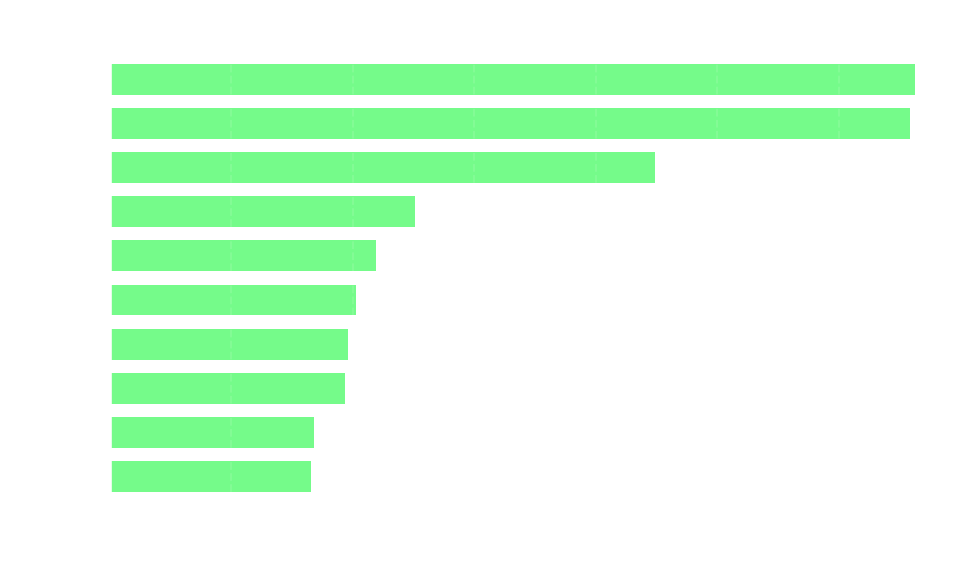

In [17]:
get_imputation_features_xgb(df_encoded, 'INCOME3', 'INCOME3_Feature_Importance', is_categorical=True)

Based on the elbow point, seems like the significant drop off happened after the _URBSTAT feautre, so for INCOME3 we will be using these features:

['PRIMINS2', 'EDUCA', 'MARITAL', 'GENHLTH', '_AGE_G', 'EXERANY2', 'SEXVAR', '_URBSTAT']

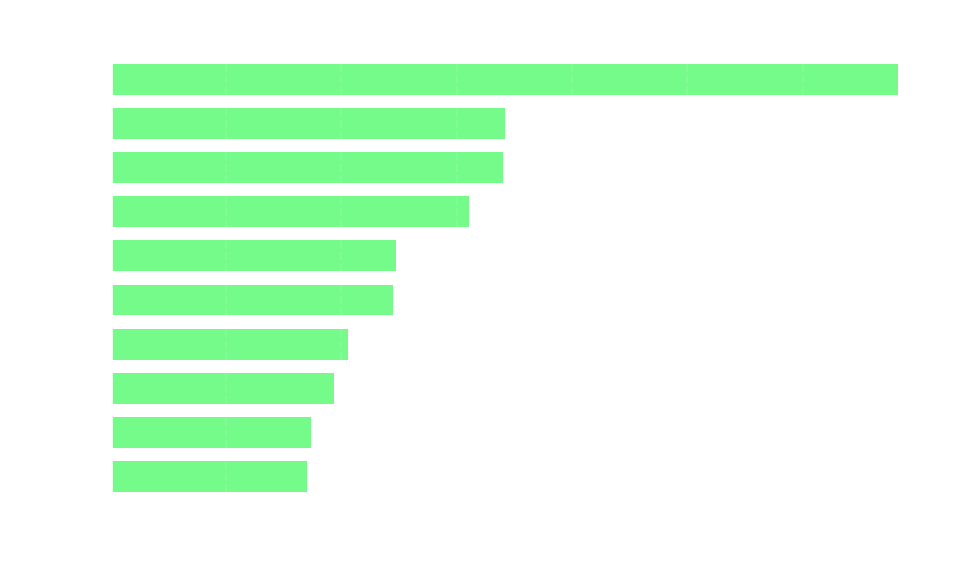

In [18]:
get_imputation_features_xgb(df_encoded, '_BMI5', 'BMI5_Feature_Importance', is_categorical=False)

Based on the elbow point, seems like the significant drop off happened after the _SMOKER3 feature, so for _BMI5 we will be using these features:

['GENHLTH', 'EXERANY2', 'HAVARTH4', '_AGE_G', 'ASTHMA3', '_SMOKER3']

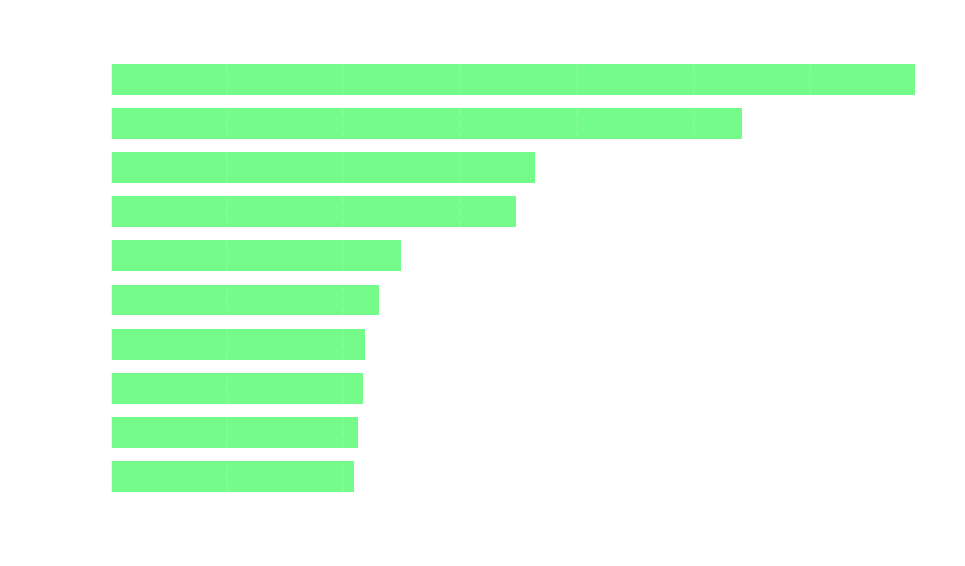

In [19]:
get_imputation_features_xgb(df_encoded, '_SMOKER3', 'SMOKER3_Feature_Importance', is_categorical=True)

Based on the elbow point, seems like the significant drop off happened after the HAVARTH4 feature, so for _SMOKER3 we will be using these features:

['_AGE_G', 'EDUCA', 'ADDEPEV3', 'SEXVAR', 'HAVARTH4']

## Conclusion

After doing missing feature analysis, we have decided to experiment with keeping unknown labels and imputation because its clearly not a MCAR case. For the imputation, based on the feature importance analysis and judging by the elbow points, we have decided to use these set of features for each alarming columns.

**INCOME3**

['PRIMINS2', 'EDUCA', 'MARITAL', 'GENHLTH', '_AGE_G', 'EXERANY2', 'SEXVAR', '_URBSTAT']

**_BMI5**

['GENHLTH', 'EXERANY2', 'HAVARTH4', '_AGE_G', 'ASTHMA3', '_SMOKER3']

**_SMOKER3**

['_AGE_G', 'EDUCA', 'ADDEPEV3', 'SEXVAR', 'HAVARTH4']